In [1]:
import torch
print("CUDA available: ",torch.cuda.is_available())
print("CUDA device count: ",torch.cuda.device_count())
import sys
print(sys.executable)

CUDA available:  True
CUDA device count:  1
C:\Users\manoj\anaconda3\envs\gmtc\python.exe


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torchvision.models as models

# For SLIC superpixels
from skimage.segmentation import slic
from skimage.measure import regionprops
from skimage import color

# Graph processing
import torch_geometric
from torch_geometric.nn import GCNConv, GATConv
from torch_geometric.data import Data
import networkx as nx

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import mediapipe as mp
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import os
import json
import pickle
from tqdm import tqdm
import warnings
import math
warnings.filterwarnings('ignore')

# Transformers for T5 translation
from transformers import T5Tokenizer, T5ForConditionalGeneration

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
print(f"Using device: {device}")

C:\Users\manoj\anaconda3\envs\gmtc\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [3]:
LANDMARK_CSV = "isl_landmarks.csv"
landmark_dict = {}

if os.path.exists(LANDMARK_CSV):

    landmark_df = pd.read_csv(LANDMARK_CSV)

    # Detect format
    old_columns = [c for c in landmark_df.columns if c.startswith(("x","y","z"))]
    new_columns = [c for c in landmark_df.columns if c.startswith(("h1_","h2_"))]

    if len(new_columns) == 126:
        landmark_columns = new_columns
        print(f"✅ New format detected — 126 values (both hands)")

    elif len(old_columns) == 63:
        landmark_columns = old_columns
        print(f"✅ Old format detected — 63 values (one hand)")

    else:
        landmark_columns = old_columns + new_columns
        print(f"⚠️ Mixed format — {len(landmark_columns)} columns found")

    print(f"Detected {len(landmark_columns)} landmark columns")

    for i in range(len(landmark_df)):

        row      = landmark_df.iloc[i]
        img_path = str(row["image_path"]).replace("\\", "/")
        coords   = row[landmark_columns].values.astype(np.float32)

        # ✅ Standardize everything to 126
        if coords.shape[0] == 63:
            # Pad second hand with zeros
            coords = np.concatenate([
                coords,
                np.zeros(63, dtype=np.float32)
            ])

        if coords.shape[0] == 126:
            landmark_dict[img_path] = coords

    print(f"✅ Loaded {len(landmark_dict)} landmark entries (all 126-dim)")

else:
    print("⚠️ isl_landmarks.csv not found — landmarks disabled")

✅ New format detected — 126 values (both hands)
Detected 126 landmark columns
✅ Loaded 41929 landmark entries (all 126-dim)


In [4]:
# ============================================================
# Dataset Path Setup
# ============================================================

import os

DATASET_PATH = "Indian"

classes = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
    and not d.startswith(".")   # <-- IMPORTANT FIX
])

print("Number of classes:", len(classes))
print(classes)

Number of classes: 35
['1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [5]:
# ============================================================
# Core Imports and Environment Setup
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import autocast, GradScaler

import torchvision.transforms as transforms
import torchvision.models as models

# SLIC Superpixel Processing
from skimage.segmentation import slic
from skimage.measure import regionprops
from skimage import color
import cv2

# Graph processing
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data, Batch

# General utilities
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm

import os
import pickle
import random
import warnings
import math
import time

warnings.filterwarnings("ignore")

# ============================================================
# Device Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"🚀 Using device: {device}")

if torch.cuda.is_available():

    gpu_name = torch.cuda.get_device_name(0)

    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9

    print(f"GPU: {gpu_name}")
    print(f"GPU Memory: {total_mem:.2f} GB")

else:

    print("⚠️ Running on CPU (training will be slow)")

🚀 Using device: cuda
GPU: NVIDIA GeForce RTX 2050
GPU Memory: 4.29 GB


In [6]:
class OptimizedSLICExtractor:
    """
    Optimized SLIC Superpixel Extractor
    Pre-computes superpixels and caches them for faster training
    """

    def __init__(self, n_segments=50, compactness=10, sigma=1,
                 cache_dir="./slic_cache"):

        self.n_segments = n_segments
        self.compactness = compactness
        self.sigma = sigma
        self.cache_dir = cache_dir

        os.makedirs(cache_dir, exist_ok=True)

        print(f"✅ OptimizedSLICExtractor initialized (segments={n_segments})")

    # ---------------------------------------------------------
    # Cache file path
    # ---------------------------------------------------------

    def get_cache_path(self, image_path):

        import hashlib

        path_hash = hashlib.md5(image_path.encode()).hexdigest()

        return os.path.join(
            self.cache_dir,
            f"slic_{path_hash}_{self.n_segments}.pkl"
        )

    # ---------------------------------------------------------
    # Cached extraction
    # ---------------------------------------------------------

    def extract_superpixels_cached(self, image_path):

        cache_path = self.get_cache_path(image_path)

        # Load from cache if available
        if os.path.exists(cache_path):

            try:
                with open(cache_path, "rb") as f:
                    return pickle.load(f)

            except:
                pass

        # Compute SLIC
        image = cv2.imread(image_path)

        if image is None:
            return None, None, None

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = cv2.resize(image, (224,224))

        segments = slic(
            image,
            n_segments=self.n_segments,
            compactness=self.compactness,
            sigma=self.sigma,
            start_label=1
        )

        features = self.extract_superpixel_features(image, segments)

        adjacency = self.create_graph_adjacency(segments, features)

        result = (segments, features, adjacency)

        # Save to cache
        try:
            with open(cache_path,"wb") as f:
                pickle.dump(result,f)
        except:
            pass

        return result

    # ---------------------------------------------------------
    # Feature extraction
    # ---------------------------------------------------------

    def extract_superpixel_features(self, image, segments):

        features = []

        props = regionprops(
            segments,
            intensity_image=color.rgb2gray(image)
        )

        for prop in props:

            centroid = prop.centroid
            area = prop.area
            bbox = prop.bbox

            mask = segments == prop.label

            # Mean color
            if np.any(mask):
                mean_color = np.mean(image[mask], axis=0)
            else:
                mean_color = np.zeros(3)

            # Texture feature
            intensity_values = prop.intensity_image[prop.image]

            texture_std = (
                np.std(intensity_values)
                if intensity_values.size > 0 else 0
            )

            feature_vector = np.concatenate([

                centroid,        # 2
                [area],          # 1
                mean_color,      # 3
                [texture_std],   # 1
                bbox             # 4

            ])

            features.append(feature_vector)

        # Ensure correct output shape
        if len(features) == 0:
            return np.zeros((0,11))

        return np.array(features)

    # ---------------------------------------------------------
    # Graph adjacency
    # ---------------------------------------------------------

    def create_graph_adjacency(self, segments, features):

        if features is None or len(features) == 0:
            return np.zeros((0,0))

        n = len(features)

        adjacency = np.zeros((n,n))

        threshold = np.sqrt(
            segments.shape[0] * segments.shape[1]
        ) / 8

        for i in range(n):

            for j in range(i+1,n):

                dist = np.linalg.norm(
                    features[i][:2] - features[j][:2]
                )

                if dist < threshold:

                    adjacency[i,j] = 1
                    adjacency[j,i] = 1

        return adjacency

In [7]:
class OptimizedGCNModule(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim,
                 num_layers=2, dropout=0.3):

        super().__init__()

        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(input_dim, hidden_dim))

        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))

        if num_layers > 1:
            self.convs.append(GCNConv(hidden_dim, output_dim))

        self.batch_norms = nn.ModuleList()

        for i in range(num_layers):
            dim = hidden_dim if i < num_layers - 1 else output_dim
            self.batch_norms.append(nn.BatchNorm1d(dim))

        self.activation = nn.ReLU()
        self.dropout_layer = nn.Dropout(dropout)

        print(f"✅ OptimizedGCNModule initialized ({input_dim}→{hidden_dim}→{output_dim})")


    def forward(self, x, edge_index):

        if x.size(0) == 0 or edge_index.size(1) == 0:
            return torch.zeros(
                (0, self.convs[-1].out_channels),
                device=x.device
            )

        for i, (conv, bn) in enumerate(zip(self.convs, self.batch_norms)):

            x = conv(x, edge_index)

            if x.size(0) > 1:
                x = bn(x)

            if i < len(self.convs) - 1:
                x = self.activation(x)
                x = self.dropout_layer(x)

        return x

class OptimizedMHSA(nn.Module):

    def __init__(self, embed_dim, num_heads, dropout=0.1):

        super().__init__()

        assert embed_dim % num_heads == 0

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = math.sqrt(self.head_dim)

        self.qkv_proj = nn.Linear(embed_dim, embed_dim * 3)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(embed_dim)

        print(f"✅ OptimizedMHSA initialized (heads={num_heads}, dim={embed_dim})")


    def forward(self, x):

        batch_size, seq_len, embed_dim = x.size()

        residual = x

        qkv = self.qkv_proj(x)

        qkv = qkv.reshape(
            batch_size, seq_len, 3,
            self.num_heads, self.head_dim
        )

        qkv = qkv.permute(2,0,3,1,4)

        Q, K, V = qkv

        attention_scores = torch.matmul(
            Q, K.transpose(-2,-1)
        ) / self.scale

        attention_weights = F.softmax(
            attention_scores, dim=-1
        )

        attention_weights = self.dropout(
            attention_weights
        )

        attended = torch.matmul(
            attention_weights, V
        )

        attended = attended.transpose(1,2).contiguous()

        attended = attended.view(
            batch_size, seq_len, embed_dim
        )

        output = self.out_proj(attended)

        output = self.layer_norm(
            output + residual
        )

        return output

class OptimizedGrainModule(nn.Module):

    def __init__(self, input_channels=3,
                 backbone="resnet34",
                 pretrained=True):

        super().__init__()

        if backbone == "resnet34":

            weights = models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
            resnet = models.resnet34(weights=weights)

            self.feature_dim = 512

        elif backbone == "resnet50":

            weights = models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
            resnet = models.resnet50(weights=weights)

            self.feature_dim = 2048

        else:

            raise ValueError(
                f"Unsupported backbone: {backbone}"
            )

        self.backbone = nn.Sequential(
            *list(resnet.children())[:-2]
        )

        self.global_avg_pool = nn.AdaptiveAvgPool2d((1,1))

        print(f"✅ OptimizedGrainModule initialized ({backbone}, features={self.feature_dim})")


    def forward(self, x):

        features = self.backbone(x)

        features = self.global_avg_pool(features)

        features = torch.flatten(features,1)

        return features

class OptimizedIRFFN(nn.Module):

    def __init__(self, input_dim, expand_ratio=4, dropout=0.1):

        super().__init__()

        hidden_dim = input_dim * expand_ratio

        self.irffn = nn.Sequential(

            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, input_dim),
            nn.Dropout(dropout)

        )

        self.layer_norm = nn.LayerNorm(input_dim)

        print(f"✅ OptimizedIRFFN initialized (dim={input_dim}, expand={expand_ratio}x)")


    def forward(self, x):

        residual = x

        x = self.irffn(x)

        x = self.layer_norm(x + residual)

        return x

In [8]:
# ============================================================
# Prototype Guided Metric Learning
# ============================================================

class PrototypeLayer(nn.Module):

    def __init__(self, feature_dim, num_classes, temperature=10.0):

        super().__init__()

        self.num_classes = num_classes
        self.feature_dim = feature_dim
        self.temperature = temperature

        # Learnable class prototypes
        self.prototypes = nn.Parameter(
            torch.empty(num_classes, feature_dim)
        )

        # Xavier initialization for stability
        nn.init.xavier_uniform_(self.prototypes)

        print(f"✅ PrototypeLayer initialized ({num_classes} classes)")


    def forward(self, x):

        # Normalize features
        x = F.normalize(x, dim=1)

        # Normalize prototypes
        p = F.normalize(self.prototypes, dim=1)

        # Compute pairwise Euclidean distance
        dist = torch.cdist(x, p)

        # Convert distance to logits
        logits = -dist * self.temperature

        return logits

In [9]:
class OptimizedGmTCModel(nn.Module):

    def __init__(self, num_classes,
                 input_channels=3,
                 backbone='resnet34',
                 graph_hidden_dim=128,
                 attention_heads=4,
                 dropout=0.3,
                 slic_segments=30):

        super().__init__()

        self.num_classes = num_classes

        # SLIC extractor
        self.slic_extractor = OptimizedSLICExtractor(
            n_segments=slic_segments,
            compactness=10,
            sigma=1
        )

        # CNN backbone
        self.grain_module = OptimizedGrainModule(
            input_channels=input_channels,
            backbone=backbone,
            pretrained=True
        )

        cnn_dim = self.grain_module.feature_dim

        # Landmark branch
        # ✅ New — accepts both hands
        self.landmark_fc = nn.Sequential(
            nn.Linear(126, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 128)
        )

        # Graph network
        self.gcn = OptimizedGCNModule(
            input_dim=11,
            hidden_dim=graph_hidden_dim//2,
            output_dim=graph_hidden_dim,
            dropout=dropout
        )

        # Combined feature dimension
        combined_dim = cnn_dim + graph_hidden_dim + 128

        # Attention
        self.mhsa = OptimizedMHSA(
            embed_dim=combined_dim,
            num_heads=attention_heads,
            dropout=dropout
        )

        # Feature refinement
        self.feature_refiner = OptimizedIRFFN(
            input_dim=combined_dim,
            expand_ratio=2,
            dropout=dropout
        )

        # Prototype classifier
        self.prototype_layer = PrototypeLayer(
            combined_dim,
            num_classes
        )

        print("✅ OptimizedGmTCModel initialized")

    # -----------------------------------------------------
    # Geometry normalization
    # -----------------------------------------------------

    def normalize_landmarks(self, landmarks):

        # ---- Hand 1 ----
        lm1    = landmarks[:, :63].view(-1, 21, 3)
        wrist1 = lm1[:, 0:1, :]
        lm1    = lm1 - wrist1
        scale1 = torch.norm(lm1[:, 9, :], dim=1, keepdim=True).unsqueeze(2)
        lm1    = lm1 / (scale1 + 1e-6)
    
        # ---- Hand 2 ----
        lm2    = landmarks[:, 63:].view(-1, 21, 3)
        has_hand2 = (lm2.sum(dim=[1,2]) != 0).float().unsqueeze(1).unsqueeze(2)
        wrist2 = lm2[:, 0:1, :]
        lm2    = lm2 - wrist2
        scale2 = torch.norm(lm2[:, 9, :], dim=1, keepdim=True).unsqueeze(2)
        lm2    = (lm2 / (scale2 + 1e-6)) * has_hand2
    
        return torch.cat([
            lm1.view(landmarks.size(0), -1),
            lm2.view(landmarks.size(0), -1)
        ], dim=1)

    # -----------------------------------------------------
    # Graph processing
    # -----------------------------------------------------
    def process_graph_features(self, image_paths, device):

        graph_features_list = []
    
        for path in image_paths:
    
            seg, sp_feat, adj = self.slic_extractor.extract_superpixels_cached(path)
    
            if sp_feat is None or len(sp_feat) == 0:
                graph_features_list.append(
                    torch.zeros(self.gcn.convs[-1].out_channels)
                )
                continue
    
            nodes = torch.tensor(sp_feat, dtype=torch.float32)
    
            edge_index = np.stack(np.where(adj > 0))
            edge_index = torch.tensor(edge_index, dtype=torch.long)
    
            nodes = nodes.to(device)
            edge_index = edge_index.to(device)
    
            gcn_out = self.gcn(nodes, edge_index)
    
            graph_feat = gcn_out.mean(dim=0)
    
            graph_features_list.append(graph_feat)
    
        graph_features = torch.stack(graph_features_list)
    
        return graph_features
    # -----------------------------------------------------
    # Forward pass
    # -----------------------------------------------------

    def forward(self,x,image_paths=None,landmarks=None):

        b = x.size(0)

        # CNN branch
        cnn_feats = self.grain_module(x)

    
        graph_feats = torch.zeros(
            b,
            self.gcn.convs[-1].out_channels,
            device=x.device
            )

        # Landmark branch
        if landmarks is not None:

            lm = self.normalize_landmarks(landmarks)

            landmark_feats = self.landmark_fc(lm)

        else:

            landmark_feats = torch.zeros(
                b,
                128,
                device=x.device
            )

        # Feature fusion
        combined = torch.cat(
            [cnn_feats,graph_feats,landmark_feats],
            dim=1
        )

        # Attention
        attn_out = self.mhsa(
            combined.unsqueeze(1)
        ).squeeze(1)

        # Feature refinement
        refined = self.feature_refiner(attn_out)

        # Prototype classifier
        output = self.prototype_layer(refined)

        return output

In [10]:
class GmTCDataset(Dataset):
    """
    Dataset for OptimizedGmTC
    Uses pre-split image paths (no internal splitting)
    """

    def __init__(self, data_paths, labels, img_size=224, split="train"):

        self.data_paths = data_paths
        self.labels = labels
        self.img_size = img_size
        self.split = split

        # cache raw images
        self.image_cache = {}

        # ------------------------------------------------
        # Image Transformations
        # ------------------------------------------------

        if split == "train":

            self.transform = transforms.Compose([

                transforms.Resize((256,256)),

                transforms.RandomResizedCrop(
                    224,
                    scale=(0.6,1.0)
                ),

                transforms.RandomHorizontalFlip(),

                transforms.RandomRotation(30),
                transforms.RandomPerspective(
                    distortion_scale=0.4,
                    p=0.5
                ),
                transforms.ColorJitter(
                    brightness=0.4,
                    contrast=0.4,
                    saturation=0.3,
                    hue=0.1
                ),
                transforms.GaussianBlur(3),
                transforms.ToTensor(),

                transforms.Normalize(
                    mean=[0.485,0.456,0.406],
                    std=[0.229,0.224,0.225]
                ),
            ])

        else:

            self.transform = transforms.Compose([

                transforms.Resize((img_size,img_size)),

                transforms.ToTensor(),

                transforms.Normalize(
                    mean=[0.485,0.456,0.406],
                    std=[0.229,0.224,0.225]
                )

            ])

        print(f"✅ Dataset loaded: {len(self.data_paths)} samples ({split})")


    # ============================================================
    # Dataset length
    # ============================================================

    def __len__(self):

        return len(self.data_paths)


    # ============================================================
    # Get item
    # ============================================================

    def __getitem__(self, idx):

        img_path = self.data_paths[idx].replace("\\","/")
        label = self.labels[idx]

        try:

            # ------------------------------------------------
            # RAW image caching
            # ------------------------------------------------

            if img_path in self.image_cache:
                raw_image = self.image_cache[img_path]

            else:
                raw_image = Image.open(img_path).convert("RGB")
                self.image_cache[img_path] = raw_image

            # Apply transforms
            image = self.transform(raw_image)

            # ------------------------------------------------
            # Landmarks
            # ------------------------------------------------

            landmarks = landmark_dict.get(
                img_path,
                np.zeros(126,dtype=np.float32)
            )

            landmarks = torch.tensor(
                landmarks,
                dtype=torch.float32
            )

            return {

                "image": image,
                "label": label,
                "image_path": img_path,
                "landmarks": landmarks

            }

        except Exception as e:

            print(f"Error loading {img_path}: {e}")

            default_image = torch.zeros(
                3,
                self.img_size,
                self.img_size
            )

            return {

                "image": default_image,
                "label": label,
                "image_path": img_path,
                "landmarks": torch.zeros(63)

            }


# ============================================================
# Collate function
# ============================================================

def gmtc_collate_fn(batch):

    images = torch.stack([item["image"] for item in batch])

    labels = torch.tensor([item["label"] for item in batch])

    image_paths = [item["image_path"] for item in batch]

    landmarks = torch.stack([item["landmarks"] for item in batch])

    return {

        "images": images,
        "labels": labels,
        "image_paths": image_paths,
        "landmarks": landmarks

    }

In [11]:
class OptimizedGmTCTrainer:

    def __init__(self, model, device='cuda', use_mixed_precision=True):

        self.model = model.to(device)
        self.device = device
        self.use_mixed_precision = use_mixed_precision

        self.scaler = GradScaler() if use_mixed_precision else None

        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []

        self.best_val_acc = 0
        self.patience_counter = 0

        print("✅ OptimizedGmTCTrainer initialized")


    # ---------------------------------------------------------
    # Training Epoch
    # ---------------------------------------------------------

    def train_epoch(self, train_loader, optimizer, criterion):

        self.model.train()

        total_loss = 0
        correct = 0
        total = 0

        pbar = tqdm(train_loader, desc="Training GmTC", leave=False)

        for batch in pbar:

            images = batch["images"].to(self.device, non_blocking=True)
            labels = batch["labels"].to(self.device, non_blocking=True)
            image_paths = batch["image_paths"]
            landmarks = batch["landmarks"].to(self.device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            # -------------------------------
            # Mixed Precision Training
            # -------------------------------

            if self.use_mixed_precision:

                with autocast():

                    outputs = self.model(images, image_paths, landmarks)
                    loss = criterion(outputs, labels)

                self.scaler.scale(loss).backward()

                # Gradient clipping
                self.scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)

                self.scaler.step(optimizer)
                self.scaler.update()

            else:

                outputs = self.model(images, image_paths, landmarks)
                loss = criterion(outputs, labels)

                loss.backward()

                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)

                optimizer.step()

            total_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            pbar.set_postfix({
                "Loss": f"{loss.item():.4f}",
                "Acc": f"{100.*correct/total:.2f}%"
            })

        epoch_loss = total_loss / len(train_loader)
        epoch_acc = 100 * correct / total

        self.train_losses.append(epoch_loss)
        self.train_accuracies.append(epoch_acc)

        return epoch_loss, epoch_acc


    # ---------------------------------------------------------
    # Validation Epoch
    # ---------------------------------------------------------

    def validate_epoch(self, val_loader, criterion):

        self.model.eval()

        total_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for batch in tqdm(val_loader, desc="Validating GmTC", leave=False):

                images = batch["images"].to(self.device, non_blocking=True)
                labels = batch["labels"].to(self.device, non_blocking=True)
                image_paths = batch["image_paths"]
                landmarks = batch["landmarks"].to(self.device, non_blocking=True)

                if self.use_mixed_precision:

                    with autocast():

                        outputs = self.model(images, image_paths, landmarks)
                        loss = criterion(outputs, labels)

                else:

                    outputs = self.model(images, image_paths, landmarks)
                    loss = criterion(outputs, labels)

                total_loss += loss.item()

                _, predicted = outputs.max(1)

                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        epoch_loss = total_loss / len(val_loader)
        epoch_acc = 100 * correct / total

        self.val_losses.append(epoch_loss)
        self.val_accuracies.append(epoch_acc)

        return epoch_loss, epoch_acc

In [12]:
from sklearn.model_selection import train_test_split

def run_optimized_gmtc_training(data_path, classes, epochs=25, batch_size=16):

    print("OPTIMIZED GmTC TRAINING PIPELINE")
    print("=" * 60)

    start_time = time.time()

    # ----------------------------------------------------
    # Step 1: Initialize SLIC extractor
    # ----------------------------------------------------

    print("\nStep 1: Initializing SLIC superpixel extractor")

    slic_extractor = OptimizedSLICExtractor(
        n_segments=15,
        cache_dir="./slic_cache"
    )

    # ----------------------------------------------------
    # Step 2: Build dataset split
    # ----------------------------------------------------

    print("\nStep 2: Preparing dataset")

    train_paths = []
    train_labels = []

    val_paths = []
    val_labels = []

    for class_idx, class_name in enumerate(classes):

        class_path = os.path.join(data_path, class_name)

        images = [
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
        ]
        if len(images) > 400:
            indices = np.linspace(0, len(images)-1, 400, dtype=int)
            images  = [images[i] for i in indices]
        
        # ✅ Sequential split — no leakage
        n          = len(images)
        split_idx  = int(0.8 * n)
        train_imgs = images[:split_idx]
        val_imgs   = images[split_idx:]

        for img in train_imgs:
            train_paths.append(os.path.join(class_path, img))
            train_labels.append(class_idx)

        for img in val_imgs:
            val_paths.append(os.path.join(class_path, img))
            val_labels.append(class_idx)

    print(f"Training samples: {len(train_paths)}")
    print(f"Validation samples: {len(val_paths)}")

    # ----------------------------------------------------
    # Overlap Check (VERY IMPORTANT)
    # ----------------------------------------------------

    overlap = len(set(train_paths) & set(val_paths))
    print(f"\nOverlap between train and validation: {overlap}")

    if overlap > 0:
        print("⚠️ WARNING: Train and validation sets overlap!")

    # ----------------------------------------------------
    # Step 3: Dataset objects
    # ----------------------------------------------------

    train_dataset = GmTCDataset(train_paths, train_labels, split="train")
    val_dataset   = GmTCDataset(val_paths, val_labels, split="val")

    # ----------------------------------------------------
    # Step 4: DataLoaders
    # ----------------------------------------------------

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=gmtc_collate_fn,
        num_workers=0,
        pin_memory=True,
        drop_last=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=gmtc_collate_fn,
        num_workers=0,
        pin_memory=True
    )

    # ----------------------------------------------------
    # Step 5: Initialize model
    # ----------------------------------------------------

    print("\nStep 3: Initializing OptimizedGmTC model")

    model = OptimizedGmTCModel(
        num_classes=len(classes),
        input_channels=3,
        backbone="resnet34",
        graph_hidden_dim=128,
        attention_heads=4,
        dropout=0.3,
        slic_segments=15
    )

    # ----------------------------------------------------
    # Step 6: Loss + Optimizer
    # ----------------------------------------------------

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=5e-4,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    # ----------------------------------------------------
    # Step 7: Trainer
    # ----------------------------------------------------

    print("\nStep 4: Initializing trainer")

    trainer = OptimizedGmTCTrainer(
        model,
        device=device,
        use_mixed_precision=True
    )

    # ----------------------------------------------------
    # Step 8: Training loop
    # ----------------------------------------------------

    print("\nStep 5: Training model")

    best_acc         = 0
    patience_counter = 0
    PATIENCE         = 5

    for epoch in range(epochs):

        print(f"\nEpoch {epoch+1}/{epochs}")

        train_loss, train_acc = trainer.train_epoch(
            train_loader,
            optimizer,
            criterion
        )

        val_loss, val_acc = trainer.validate_epoch(
            val_loader,
            criterion
        )

        scheduler.step()

        print(
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Val Acc: {val_acc:.2f}%"
        )

        if val_acc > best_acc:
            best_acc         = val_acc
            patience_counter = 0
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "val_acc":          val_acc,
                    "classes":          classes
                },
                "optimized_gmtc_model_upgrade.pth"
            )
            print(f"✅ Best model saved — Val Acc: {val_acc:.2f}%")
        
        else:
            patience_counter += 1
            print(f"⚠️ No improvement ({patience_counter}/{PATIENCE})")
            if patience_counter >= PATIENCE:
                print(f"⏹ Early stopping at epoch {epoch+1}")
                break

    # ----------------------------------------------------
    # Step 9: Load best model
    # ----------------------------------------------------

    print("\nStep 6: Loading best model")

    checkpoint = torch.load(
        "optimized_gmtc_model_upgrade.pth",
        map_location=device
    )

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    # ----------------------------------------------------
    # Step 10: Final evaluation
    # ----------------------------------------------------

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for batch in tqdm(val_loader, desc="Final evaluation"):

            images = batch["images"].to(device)
            labels = batch["labels"].to(device)
            image_paths = batch["image_paths"]
            landmarks = batch["landmarks"].to(device)

            outputs = model(images, image_paths, landmarks)

            _, predicted = outputs.max(1)

            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    final_acc = 100.0 * val_correct / val_total

    # ----------------------------------------------------
    # Results
    # ----------------------------------------------------

    total_time = time.time() - start_time

    print("\n" + "=" * 60)
    print("TRAINING COMPLETED")
    print("=" * 60)

    print(f"Training Time: {total_time/60:.2f} minutes")
    print(f"Best Validation Accuracy: {best_acc:.2f}%")
    print(f"Final Accuracy: {final_acc:.2f}%")

    return model, trainer, final_acc

In [13]:
# ============================================================
# Dataset path
# ============================================================

DATASET_PATH = "Indian"

# ------------------------------------------------------------
# Set random seed (important for reproducibility)
# ------------------------------------------------------------

import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# Load class folders
# ------------------------------------------------------------

DATASET_PATH = "Indian"

classes = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
    and not d.startswith(".")   # <-- IMPORTANT FIX
])

print("Number of classes:", len(classes))
print(classes)
# ------------------------------------------------------------
# Start training
# ------------------------------------------------------------

model, trainer, final_acc = run_optimized_gmtc_training(
    data_path=DATASET_PATH,
    classes=classes,
    epochs=50,
    batch_size=32
)

Number of classes: 35
['1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
OPTIMIZED GmTC TRAINING PIPELINE

Step 1: Initializing SLIC superpixel extractor
✅ OptimizedSLICExtractor initialized (segments=15)

Step 2: Preparing dataset
Training samples: 11200
Validation samples: 2800

Overlap between train and validation: 0
✅ Dataset loaded: 11200 samples (train)
✅ Dataset loaded: 2800 samples (val)

Step 3: Initializing OptimizedGmTC model
✅ OptimizedSLICExtractor initialized (segments=15)
✅ OptimizedGrainModule initialized (resnet34, features=512)
✅ OptimizedGCNModule initialized (11→64→128)
✅ OptimizedMHSA initialized (heads=4, dim=768)
✅ OptimizedIRFFN initialized (dim=768, expand=2x)
✅ PrototypeLayer initialized (35 classes)
✅ OptimizedGmTCModel initialized

Step 4: Initializing trainer
✅ OptimizedGmTCTrainer initialized

Step 5: Training model

Epoch 1/50


Train Loss: 0.8459 | Train Acc: 95.13% | Val Acc: 98.89%
✅ Best model saved — Val Acc: 98.89%

Epoch 2/50


Train Loss: 0.7040 | Train Acc: 99.03% | Val Acc: 99.93%
✅ Best model saved — Val Acc: 99.93%

Epoch 3/50


Train Loss: 0.7029 | Train Acc: 98.97% | Val Acc: 99.93%
⚠️ No improvement (1/5)

Epoch 4/50


Train Loss: 0.6845 | Train Acc: 99.36% | Val Acc: 100.00%
✅ Best model saved — Val Acc: 100.00%

Epoch 5/50


...

Train Loss: 0.6798 | Train Acc: 99.54% | Val Acc: 100.00%
⚠️ No improvement (3/5)

Epoch 8/50


Train Loss: 0.6888 | Train Acc: 99.38% | Val Acc: 100.00%
⚠️ No improvement (4/5)

Epoch 9/50


Train Loss: 0.6718 | Train Acc: 99.79% | Val Acc: 100.00%
⚠️ No improvement (5/5)
⏹ Early stopping at epoch 9

Step 6: Loading best model


Final evaluation: 100%|████████████████████████████████████████████████████████████████| 88/88 [00:14<00:00,  6.15it/s]



TRAINING COMPLETED
Training Time: 45.66 minutes
Best Validation Accuracy: 100.00%
Final Accuracy: 100.00%


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
from PIL import Image
import glob
import random
import torch
import torch.nn.functional as F
import os
import torchvision.transforms as transforms


class GmTCModelTester:

    """
    Testing framework for OptimizedGmTC model
    """

    def __init__(self, model_path, classes, data_path):

        self.data_path = data_path

        # Device
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        # Image preprocessing
        self.transform = transforms.Compose([

            transforms.Resize((256,256)),
        
            transforms.CenterCrop(224),
        
            transforms.ColorJitter(
                brightness=0.1,
                contrast=0.1
            ),
        
            transforms.ToTensor(),
        
            transforms.Normalize(
                mean=[0.485,0.456,0.406],
                std=[0.229,0.224,0.225]
            )
        ])

        try:

            checkpoint = torch.load(model_path, map_location=self.device)

            num_classes = checkpoint['model_state_dict']['prototype_layer.prototypes'].shape[0]

            # Use saved class order from training
            if "classes" in checkpoint:
                self.classes = checkpoint["classes"]
            else:
                self.classes = classes[:num_classes]
            self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
            self.idx_to_class = {idx: cls for cls, idx in self.class_to_idx.items()}

            # Build model
            self.model = OptimizedGmTCModel(
                num_classes=num_classes,
                backbone="resnet34",
                graph_hidden_dim=128,
                attention_heads=4,
                slic_segments=15
            )

            # Load weights
            self.model.load_state_dict(
                checkpoint["model_state_dict"],
                strict=False
            )

            print(f"✅ Model loaded successfully from {model_path}")
            print(f"🏆 Validation accuracy: {checkpoint.get('val_acc','Unknown'):.2f}%")

        except Exception as e:

            print("⚠️ Model loading failed")
            print(e)

        self.model.eval()
        self.model.to(self.device)

        print(f"🧪 GmTCModelTester initialized for {len(self.classes)} classes")


    # ============================================================
    # Single Image Test
    # ============================================================

    def test_single_image(self, image_path, show_image=True):

        try:

            image = Image.open(image_path).convert("RGB")
            original_image = image.copy()

            image_tensor = self.transform(image).unsqueeze(0).to(self.device)

            with torch.no_grad():

                img_key = image_path.replace("\\","/")

                lm = landmark_dict.get(img_key, np.zeros(63,dtype=np.float32))
                lm = torch.tensor(lm,dtype=torch.float32).unsqueeze(0).to(self.device)

                outputs = self.model(image_tensor,[image_path],lm)

                probabilities = F.softmax(outputs,dim=1)

                confidence,predicted_idx = probabilities.max(1)

            predicted_class = self.idx_to_class[predicted_idx.item()]
            confidence_score = confidence.item()

            actual_class = os.path.basename(os.path.dirname(image_path))

            is_correct = predicted_class == actual_class

            if show_image:

                plt.figure(figsize=(8,6))

                plt.imshow(original_image)
                plt.title(
                    f"Actual: {actual_class}\n"
                    f"Predicted: {predicted_class} ({confidence_score:.3f})"
                )
                plt.axis("off")
                plt.show()

            return {
                "image_path":image_path,
                "actual_class":actual_class,
                "predicted_class":predicted_class,
                "confidence":confidence_score,
                "is_correct":is_correct,
                "all_probabilities":probabilities[0].cpu().numpy()
            }

        except Exception as e:

            print(f"❌ Error testing image {image_path}: {e}")
            return None


    # ============================================================
    # Random Sample Testing
    # ============================================================

    def test_random_samples(self,num_samples=5):

        print(f"\n🎲 Testing {num_samples} random samples per class")

        results = []

        for class_name in self.classes:

            class_path = os.path.join(self.data_path,class_name)

            if not os.path.exists(class_path):
                continue

            image_files = glob.glob(os.path.join(class_path,"*.jpg")) + \
                          glob.glob(os.path.join(class_path,"*.jpeg")) + \
                          glob.glob(os.path.join(class_path,"*.png"))

            if len(image_files)==0:
                continue

            sample_files = random.sample(image_files,min(num_samples,len(image_files)))

            print(f"\n📂 Testing class: {class_name}")

            class_results = []

            for img_path in sample_files:

                result = self.test_single_image(img_path,show_image=False)

                if result:

                    class_results.append(result)

                    status = "✅" if result["is_correct"] else "❌"

                    print(f"   {status} {os.path.basename(img_path)} → {result['predicted_class']} ({result['confidence']:.3f})")

            results.extend(class_results)

        if results:

            overall_acc = sum(r["is_correct"] for r in results)/len(results)

            print(f"\n🎯 Overall Test Accuracy: {overall_acc*100:.2f}%")

        return results


    # ============================================================
    # Confusion Matrix
    # ============================================================

    def create_confusion_matrix(self,test_results):

        if not test_results:
            print("❌ No test results available")
            return

        y_true = [self.class_to_idx[r["actual_class"]] for r in test_results]
        y_pred = [self.class_to_idx[r["predicted_class"]] for r in test_results]

        labels = sorted(set(y_true)|set(y_pred))
        target_names = [self.idx_to_class[l] for l in labels]

        cm = confusion_matrix(y_true,y_pred,labels=labels)
        
        plt.figure(figsize=(12,10))

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=target_names,
            yticklabels=target_names
        )

        plt.title("Confusion Matrix - OptimizedGmTC")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")

        plt.xticks(rotation=45)
        plt.yticks(rotation=0)

        plt.tight_layout()
        plt.show()

        print("\n📊 Classification Report\n")

        print(
            classification_report(
                y_true,
                y_pred,
                labels=labels,
                target_names=target_names,
                zero_division=0
            )
        )

In [52]:
# 🚀 INITIALIZE MODEL TESTER

DATASET_PATH = "Indian"
MODEL_PATH = "optimized_gmtc_model_upgrade.pth"


# ------------------------------------------------------------
# Check dataset folder
# ------------------------------------------------------------

if not os.path.exists(DATASET_PATH):

    print(f"❌ Dataset not found at {DATASET_PATH}")
    print("Please update DATASET_PATH to your ISL dataset directory")

else:

    classes = sorted([
        d for d in os.listdir(DATASET_PATH)
        if os.path.isdir(os.path.join(DATASET_PATH, d))
        and not d.startswith(".")
    ])

    print(f"📂 Found {len(classes)} classes")

    # Show sample dataset statistics
    total_images = 0
    for cls in classes:
        cls_path = os.path.join(DATASET_PATH, cls)
        count = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith((".jpg",".jpeg",".png",".bmp"))
        ])
        total_images += count
        print(f"{cls}: {count} images")

    print(f"\n📊 Total dataset images: {total_images}")


    # --------------------------------------------------------
    # Check model file
    # --------------------------------------------------------

    if not os.path.exists(MODEL_PATH):

        print(f"\n❌ Model file not found: {MODEL_PATH}")
        print("Train the model first or update MODEL_PATH")

    else:

        # Initialize tester
        tester = GmTCModelTester(
            model_path=MODEL_PATH,
            classes=classes,
            data_path=DATASET_PATH
        )

        print("\n🧪 Model testing framework ready!")

📂 Found 35 classes
1: 1199 images
2: 1200 images
3: 1200 images
4: 1200 images
5: 1200 images
6: 1200 images
7: 1200 images
8: 1200 images
9: 1200 images
A: 1200 images
B: 1200 images
C: 1447 images
D: 1200 images
E: 1200 images
F: 1200 images
G: 1200 images
H: 1200 images
I: 1379 images
J: 1200 images
K: 1200 images
L: 1200 images
M: 1200 images
N: 1200 images
O: 1429 images
P: 1200 images
Q: 1200 images
R: 1200 images
S: 1200 images
T: 1200 images
U: 1200 images
V: 1290 images
W: 1200 images
X: 1200 images
Y: 1200 images
Z: 1200 images

📊 Total dataset images: 42744
✅ OptimizedSLICExtractor initialized (segments=15)
✅ OptimizedGrainModule initialized (resnet34, features=512)
✅ OptimizedGCNModule initialized (11→64→128)
✅ OptimizedMHSA initialized (heads=4, dim=768)
✅ OptimizedIRFFN initialized (dim=768, expand=2x)
✅ PrototypeLayer initialized (35 classes)
✅ OptimizedGmTCModel initialized
✅ Model loaded successfully from optimized_gmtc_model_upgrade.pth
🏆 Validation accuracy: 100.00%


In [53]:
# 🎯 TEST 1: Random Sample Testing
# Test the model on random images

import random
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np
import os


def test_random_images(tester, num_images=5):

    print(f"\n🎯 Testing {num_images} random images\n")

    correct = 0
    total = 0

    for i in range(num_images):

        cls = random.choice(tester.classes)
        cls_path = os.path.join(tester.data_path, cls)

        images = [
            f for f in os.listdir(cls_path)
            if f.lower().endswith((".png",".jpg",".jpeg"))
        ]

        if not images:
            continue

        img_name = random.choice(images)
        img_path = os.path.join(cls_path, img_name)

        try:

            image = Image.open(img_path).convert("RGB")

        except:
            continue

        image_tensor = tester.transform(image).unsqueeze(0).to(tester.device)

        # Load landmarks
        img_key = img_path.replace("\\","/")
        lm = landmark_dict.get(img_key, np.zeros(63,dtype=np.float32))
        lm = torch.tensor(lm,dtype=torch.float32).unsqueeze(0).to(tester.device)

        with torch.no_grad():

            outputs = tester.model(image_tensor,[img_path],lm)

            probs = F.softmax(outputs,dim=1)

            conf,idx = probs.max(1)

        predicted_idx = idx.item()

        # Safe class lookup
        predicted = tester.idx_to_class.get(predicted_idx,"UNKNOWN")

        confidence = conf.item()

        total += 1
        if predicted == cls:
            correct += 1

        plt.figure(figsize=(4,4))
        plt.imshow(image)
        plt.axis("off")

        plt.title(
            f"Actual: {cls}\nPredicted: {predicted}\nConfidence: {confidence:.3f}"
        )

        plt.show()

        print(f"✔ Image {i+1}")
        print(f"   Actual    : {cls}")
        print(f"   Predicted : {predicted}")
        print(f"   Confidence: {confidence:.3f}\n")

    if total > 0:

        acc = 100 * correct / total

        print("--------------------------------------------------")
        print(f"🎯 Random Test Accuracy: {acc:.2f}% ({correct}/{total})")
        print("--------------------------------------------------")

Number of classes: 35
['1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

🎯 Testing 10 random images



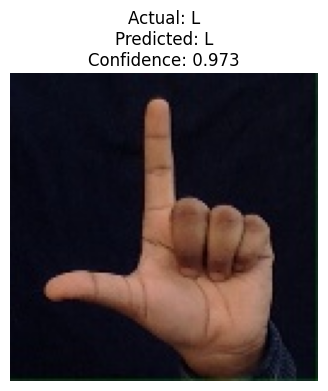

✔ Image 1
   Actual    : L
   Predicted : L
   Confidence: 0.973



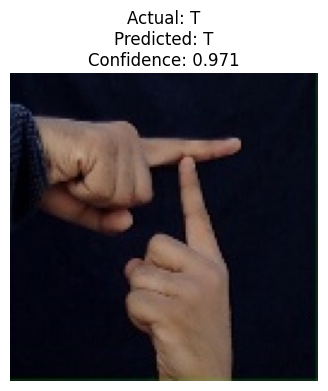

✔ Image 2
   Actual    : T
   Predicted : T
   Confidence: 0.971



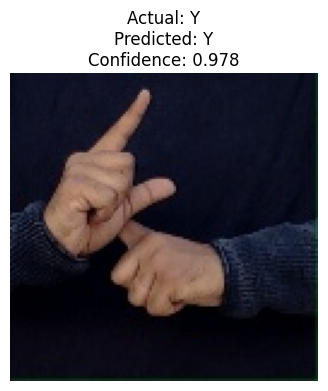

✔ Image 3
   Actual    : Y
   Predicted : Y
   Confidence: 0.978



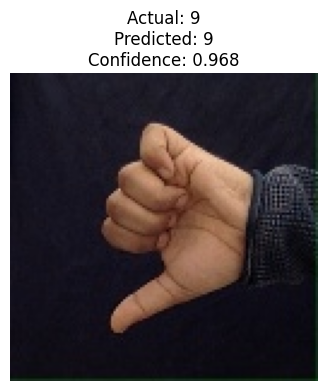

✔ Image 4
   Actual    : 9
   Predicted : 9
   Confidence: 0.968



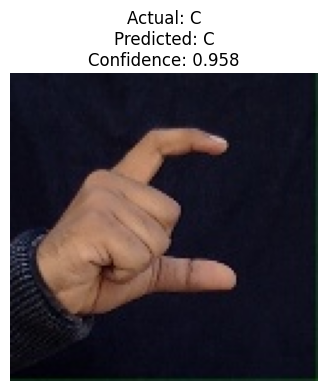

✔ Image 5
   Actual    : C
   Predicted : C
   Confidence: 0.958



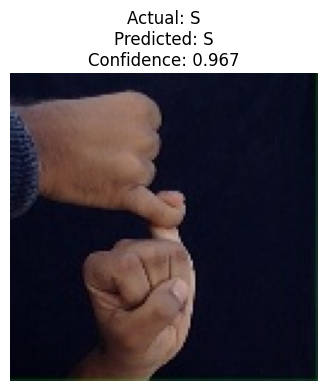

✔ Image 6
   Actual    : S
   Predicted : S
   Confidence: 0.967



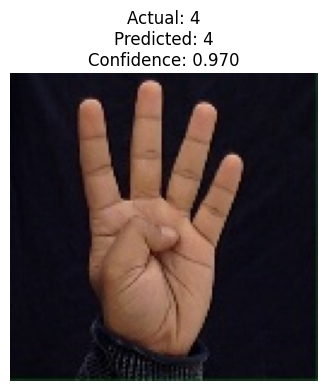

✔ Image 7
   Actual    : 4
   Predicted : 4
   Confidence: 0.970



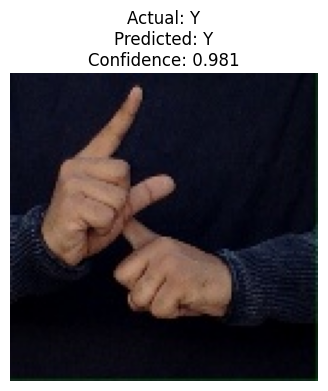

✔ Image 8
   Actual    : Y
   Predicted : Y
   Confidence: 0.981



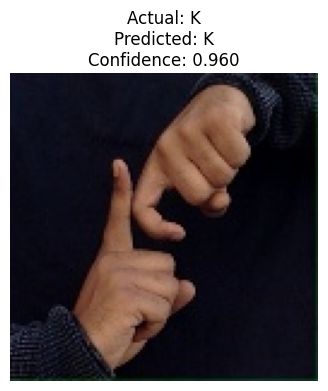

✔ Image 9
   Actual    : K
   Predicted : K
   Confidence: 0.960



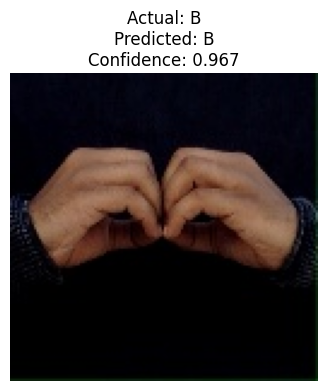

✔ Image 10
   Actual    : B
   Predicted : B
   Confidence: 0.967

--------------------------------------------------
🎯 Random Test Accuracy: 100.00% (10/10)
--------------------------------------------------


In [54]:
%matplotlib inline

print("Number of classes:", len(classes))
print(classes)

# Make sure tester is initialized
if 'tester' not in globals():
    print("❌ Tester not initialized. Run the tester initialization cell first.")
else:
    # Show random predictions
    test_random_images(tester, num_images=10)

🔍 Running random sample testing...


🎲 Testing 10 random samples per class

📂 Testing class: 1
   ✅ 334.jpg → 1 (0.971)
   ✅ 557.jpg → 1 (0.974)
   ✅ 876.jpg → 1 (0.972)
   ✅ 442.jpg → 1 (0.973)
   ✅ 1143.jpg → 1 (0.972)
   ✅ 381.jpg → 1 (0.972)
   ✅ 281.jpg → 1 (0.971)
   ✅ 935.jpg → 1 (0.972)
   ✅ 425.jpg → 1 (0.972)
   ✅ 15.jpg → 1 (0.971)

📂 Testing class: 2
   ✅ 477.jpg → 2 (0.965)
   ✅ 901.jpg → 2 (0.965)
   ✅ 117.jpg → 2 (0.966)
   ✅ 845.jpg → 2 (0.965)
   ✅ 229.jpg → 2 (0.965)
   ✅ 99.jpg → 2 (0.966)
   ✅ 201.jpg → 2 (0.964)
   ✅ 233.jpg → 2 (0.965)
   ✅ 540.jpg → 2 (0.964)
   ✅ 958.jpg → 2 (0.965)

📂 Testing class: 3
   ✅ 1073.jpg → 3 (0.969)
   ✅ 105.jpg → 3 (0.969)
   ✅ 1147.jpg → 3 (0.969)
   ✅ 1081.jpg → 3 (0.969)
   ✅ 982.jpg → 3 (0.968)
   ✅ 406.jpg → 3 (0.969)
   ✅ 306.jpg → 3 (0.969)
   ✅ 973.jpg → 3 (0.968)
   ✅ 687.jpg → 3 (0.968)
   ✅ 1053.jpg → 3 (0.969)

📂 Testing class: 4
   ✅ 836.jpg → 4 (0.970)
   ✅ 924.jpg → 4 (0.970)
   ✅ 452.jpg → 4 (0.970)
   ✅ 475.jpg → 4 

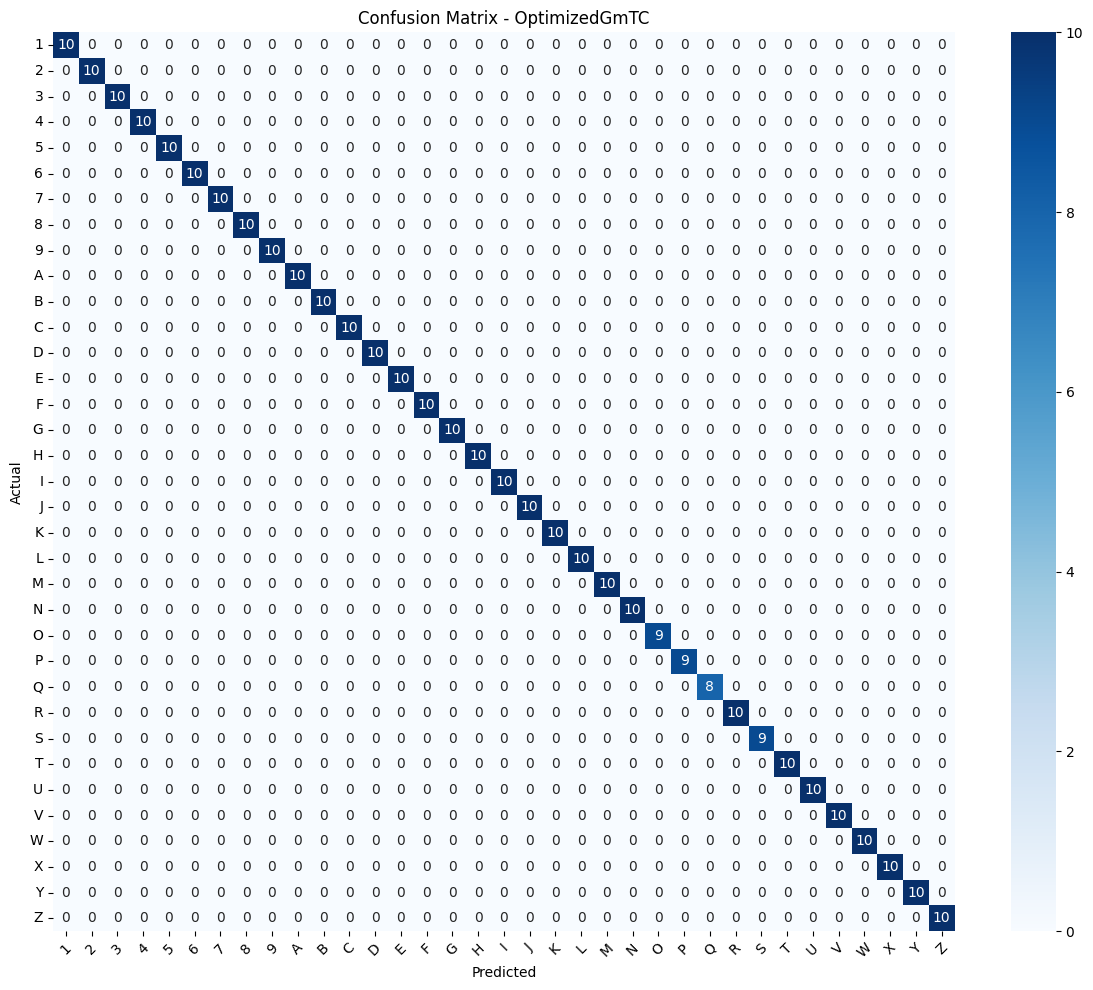


📊 Classification Report

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        10
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00        10
           7       1.00      1.00      1.00        10
           8       1.00      1.00      1.00        10
           9       1.00      1.00      1.00        10
           A       1.00      1.00      1.00        10
           B       1.00      1.00      1.00        10
           C       1.00      1.00      1.00        10
           D       1.00      1.00      1.00        10
           E       1.00      1.00      1.00        10
           F       1.00      1.00      1.00        10
           G       1.00      1.00      1.00        10
           H       1.00      1.00      1.00        10
 

In [55]:
# ============================================================
# TEST 2: Confusion Matrix Analysis
# ============================================================

print("🔍 Running random sample testing...\n")

test_results = tester.test_random_samples(num_samples=10)

# Check results before plotting
if test_results and len(test_results) > 0:

    print("\n📊 Creating confusion matrix analysis...\n")

    tester.create_confusion_matrix(test_results)

else:

    print("❌ No valid test results were generated.")




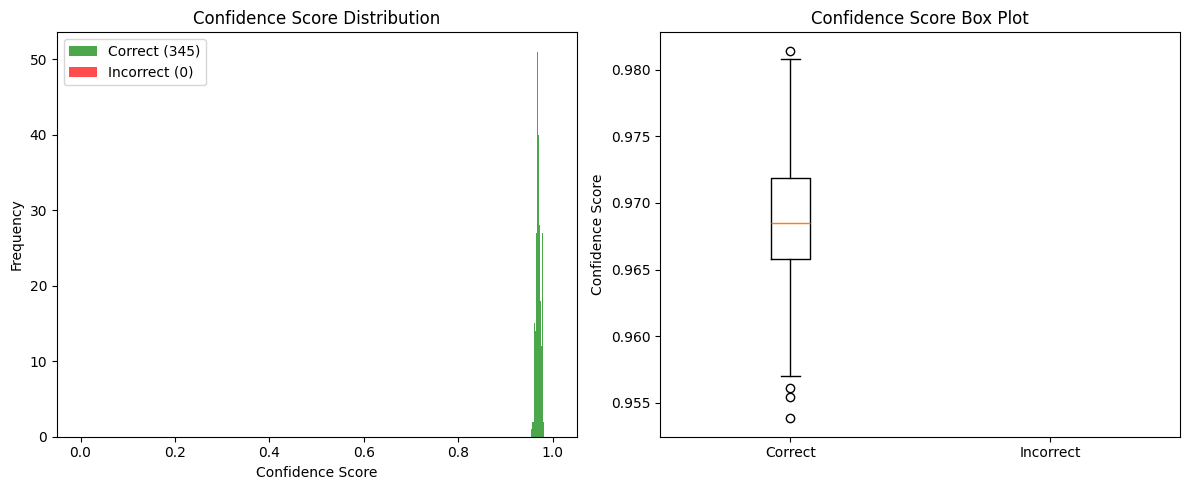

✅ Correct Predictions - Mean Confidence: 0.969 ± 0.005


In [56]:
def test_confidence_distribution(test_results):
        """Analyze confidence score distribution"""
        if not test_results:
            print("❌ No test results available for confidence analysis")
            return

        correct_confidences = [r['confidence'] for r in test_results if r['is_correct']]
        incorrect_confidences = [r['confidence'] for r in test_results if not r['is_correct']]

        plt.figure(figsize=(12, 5))

        # Confidence distribution
        plt.subplot(1, 2, 1)
        plt.hist(correct_confidences, bins=20, alpha=0.7, label=f'Correct ({len(correct_confidences)})', color='green')
        plt.hist(incorrect_confidences, bins=20, alpha=0.7, label=f'Incorrect ({len(incorrect_confidences)})', color='red')
        plt.xlabel('Confidence Score')
        plt.ylabel('Frequency')
        plt.title('Confidence Score Distribution')
        plt.legend()

        # Box plot
        plt.subplot(1, 2, 2)
        data = [correct_confidences, incorrect_confidences]
        labels = ['Correct', 'Incorrect']
        plt.boxplot(data, labels=labels)
        plt.ylabel('Confidence Score')
        plt.title('Confidence Score Box Plot')

        plt.tight_layout()
        plt.show()

        # Statistics
        if correct_confidences:
            print(f"✅ Correct Predictions - Mean Confidence: {np.mean(correct_confidences):.3f} ± {np.std(correct_confidences):.3f}")
        if incorrect_confidences:
            print(f"❌ Incorrect Predictions - Mean Confidence: {np.mean(incorrect_confidences):.3f} ± {np.std(incorrect_confidences):.3f}")

test_confidence_distribution(test_results)




🔍 Testing specific image: Indian/4/11.jpg


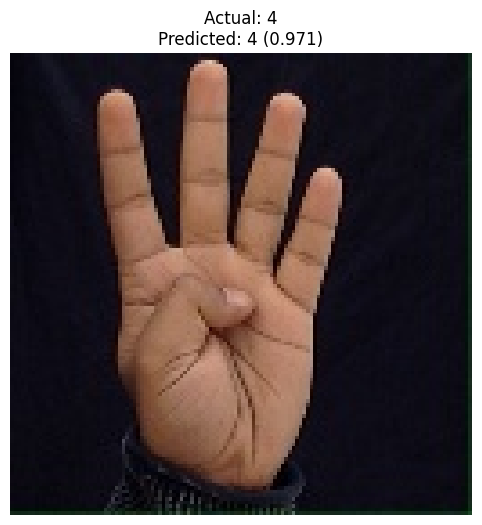


📋 Detailed Results:
   📂 Actual Class   : 4
   🎯 Predicted Class: 4
   📊 Confidence     : 0.9707
   ✅ Correct        : Yes

🏆 Top 5 Predictions:
   1. 4: 0.9707
   2. I: 0.0011
   3. Z: 0.0010
   4. 3: 0.0010
   5. M: 0.0010


In [57]:
# ============================================================
# 🔍 TEST 4: Single Image Detailed Testing
# ============================================================

def test_specific_image(image_path):
    """Test a specific image with detailed analysis"""

    print(f"🔍 Testing specific image: {image_path}")

    # Check tester
    if 'tester' not in globals():
        print("❌ Tester not initialized. Run tester initialization first.")
        return

    # Check image
    if not os.path.exists(image_path):
        print("❌ Image not found")
        return

    result = tester.test_single_image(image_path, show_image=True)

    if result:

        print("\n📋 Detailed Results:")
        print(f"   📂 Actual Class   : {result['actual_class']}")
        print(f"   🎯 Predicted Class: {result['predicted_class']}")
        print(f"   📊 Confidence     : {result['confidence']:.4f}")
        print(f"   ✅ Correct        : {'Yes' if result['is_correct'] else 'No'}")

        # Top-5 predictions
        top_5_indices = np.argsort(result['all_probabilities'])[-5:][::-1]

        print("\n🏆 Top 5 Predictions:")

        for i, idx in enumerate(top_5_indices, 1):

            class_name = tester.idx_to_class.get(idx, "UNKNOWN")
            confidence = result['all_probabilities'][idx]

            print(f"   {i}. {class_name}: {confidence:.4f}")


# ------------------------------------------------------------
# Example usage
# ------------------------------------------------------------

test_specific_image("Indian/4/11.jpg")

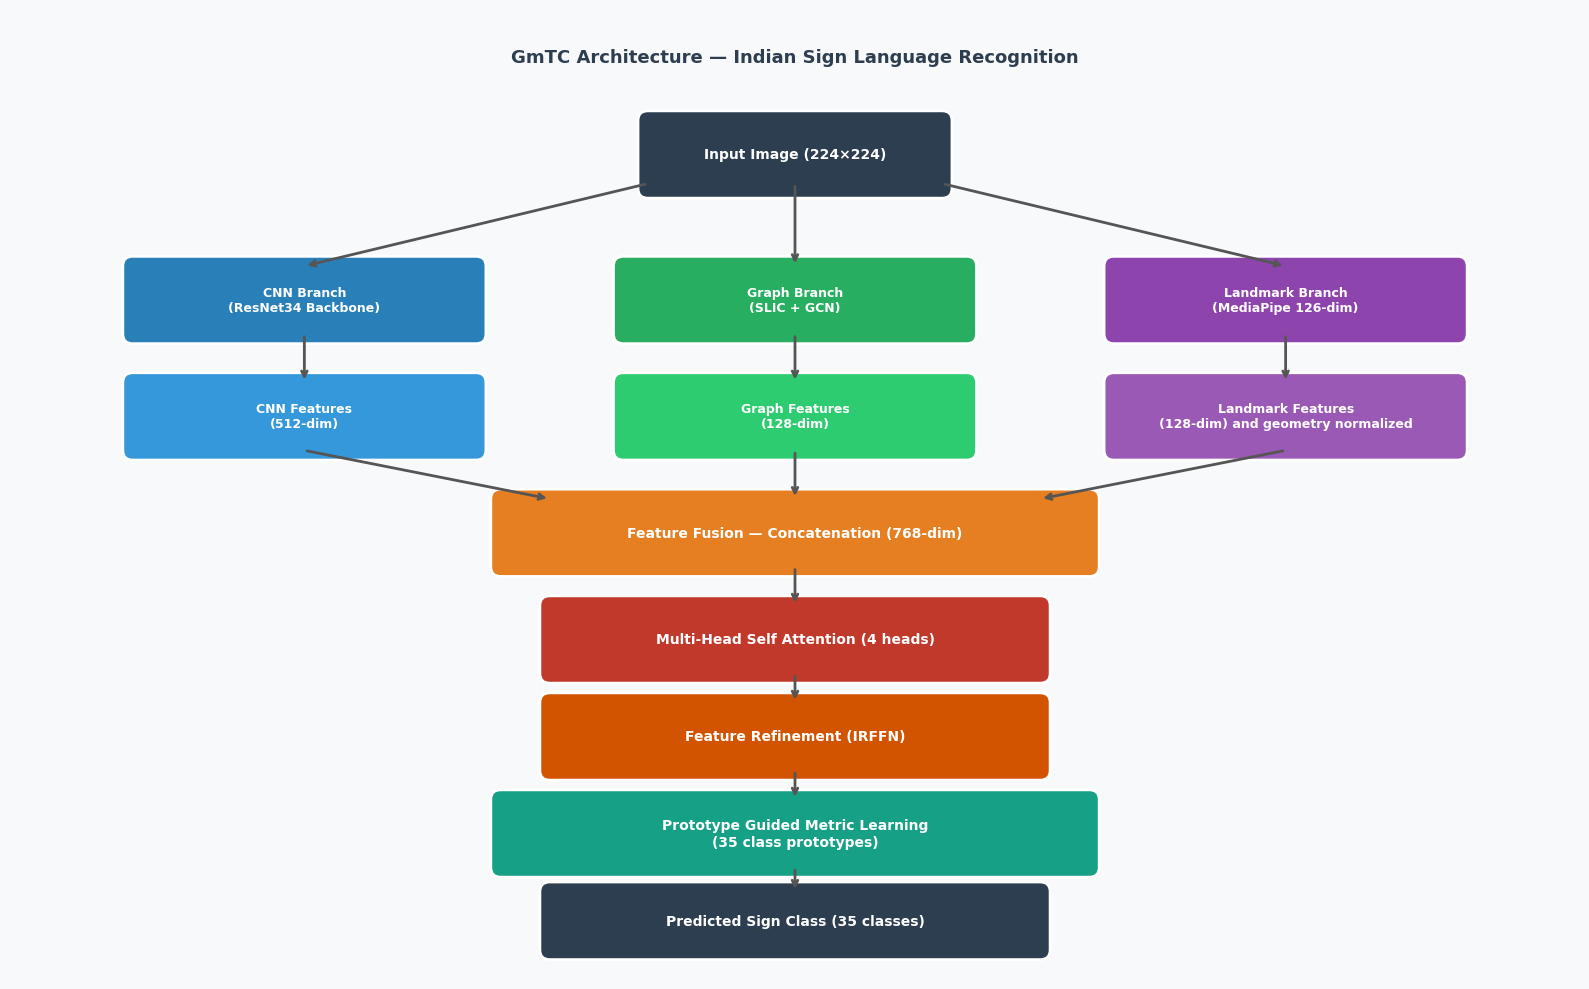

✅ Architecture diagram saved as gmtc_architecture.png


In [63]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(1, 1, figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis("off")
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("#f8f9fa")

def draw_box(ax, x, y, w, h, text, color, fontsize=9):
    box = FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle="round,pad=0.1",
        facecolor=color,
        edgecolor="white",
        linewidth=2
    )
    ax.add_patch(box)
    ax.text(
        x, y, text,
        ha="center", va="center",
        fontsize=fontsize,
        fontweight="bold",
        color="white"
    )

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate(
        "",
        xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", color="#555555", lw=2)
    )

# Title
ax.text(8, 9.5,
        "GmTC Architecture — Indian Sign Language Recognition",
        ha="center", va="center",
        fontsize=13, fontweight="bold", color="#2c3e50")

# Input
draw_box(ax, 8, 8.5, 3, 0.7, "Input Image (224×224)", "#2c3e50", 10)

# Three branches
draw_box(ax, 3,   7, 3.5, 0.7, "CNN Branch\n(ResNet34 Backbone)",     "#2980b9", 9)
draw_box(ax, 8,   7, 3.5, 0.7, "Graph Branch\n(SLIC + GCN)",          "#27ae60", 9)
draw_box(ax, 13,  7, 3.5, 0.7, "Landmark Branch\n(MediaPipe 126-dim)", "#8e44ad", 9)

# Arrows input to branches
draw_arrow(ax, 6.5, 8.2, 3,  7.35)
draw_arrow(ax, 8,   8.2, 8,  7.35)
draw_arrow(ax, 9.5, 8.2, 13, 7.35)

# Branch outputs
draw_box(ax, 3,  5.8, 3.5, 0.7, "CNN Features\n(512-dim)",       "#3498db", 9)
draw_box(ax, 8,  5.8, 3.5, 0.7, "Graph Features\n(128-dim)",     "#2ecc71", 9)
draw_box(ax, 13, 5.8, 3.5, 0.7, "Landmark Features\n(128-dim) and geometry normalized",  "#9b59b6", 9)

draw_arrow(ax, 3,  6.65, 3,  6.15)
draw_arrow(ax, 8,  6.65, 8,  6.15)
draw_arrow(ax, 13, 6.65, 13, 6.15)

# Fusion
draw_box(ax, 8, 4.6, 6, 0.7,
         "Feature Fusion — Concatenation (768-dim)", "#e67e22", 10)

draw_arrow(ax, 3,  5.45, 5.5, 4.95)
draw_arrow(ax, 8,  5.45, 8,   4.95)
draw_arrow(ax, 13, 5.45, 10.5,4.95)

# Attention
draw_box(ax, 8, 3.5, 5, 0.7,
         "Multi-Head Self Attention (4 heads)", "#c0392b", 10)
draw_arrow(ax, 8, 4.25, 8, 3.85)

# IRFFN
draw_box(ax, 8, 2.5, 5, 0.7,
         "Feature Refinement (IRFFN)", "#d35400", 10)
draw_arrow(ax, 8, 3.15, 8, 2.85)

# Prototype
draw_box(ax, 8, 1.5, 6, 0.7,
         "Prototype Guided Metric Learning\n(35 class prototypes)", "#16a085", 10)
draw_arrow(ax, 8, 2.15, 8, 1.85)

# Output
draw_box(ax, 8, 0.6, 5, 0.6,
         "Predicted Sign Class (35 classes)", "#2c3e50", 10)
draw_arrow(ax, 8, 1.15, 8, 0.9)

plt.tight_layout()
plt.savefig("gmtc_architecture.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Architecture diagram saved as gmtc_architecture.png") 

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import os
import cv2
from collections import deque
import time
import mediapipe as mp

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {device}")

# ============================================================
# CLASSES
# ============================================================

DATASET_PATH = "Indian"

classes = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
    and not d.startswith(".")
])

print(f"✅ Classes loaded: {len(classes)}")

# ============================================================
# MODEL DEFINITION
# ============================================================

class LandmarkClassifier(nn.Module):

    def __init__(self, num_classes, input_dim=126):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# ============================================================
# NORMALIZATION
# ============================================================

def normalize_landmarks(landmarks_np):

    lm1    = landmarks_np[:63].reshape(21, 3)
    wrist1 = lm1[0:1, :]
    lm1    = lm1 - wrist1
    scale1 = np.linalg.norm(lm1[9, :]) + 1e-6
    lm1    = lm1 / scale1

    lm2 = landmarks_np[63:].reshape(21, 3)
    if np.any(lm2 != 0):
        wrist2 = lm2[0:1, :]
        lm2    = lm2 - wrist2
        scale2 = np.linalg.norm(lm2[9, :]) + 1e-6
        lm2    = lm2 / scale2

    return np.concatenate([lm1.flatten(), lm2.flatten()])

# ============================================================
# LOAD SAVED MODEL
# ============================================================

lm_model = LandmarkClassifier(
    num_classes=len(classes),
    input_dim=126
).to(device)

checkpoint = torch.load(
    "landmark_classifier.pth",
    map_location=device
)

lm_model.load_state_dict(checkpoint["model_state_dict"])
lm_model.eval()

print(f"✅ Model loaded — Val Acc: {checkpoint['val_acc']:.2f}%")
print(f"🚀 Ready! Now run the webcam cell.")

✅ Device: cuda
✅ Classes loaded: 35
✅ Model loaded — Val Acc: 97.78%
🚀 Ready! Now run the webcam cell.


In [3]:
import cv2
import mediapipe as mp
import torch
import torch.nn.functional as F
import numpy as np
from collections import deque
import time

mp_hands = mp.solutions.hands

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=2,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.7
)

mp_draw = mp.solutions.drawing_utils

prediction_buffer = deque(maxlen=30)
confidence_buffer = deque(maxlen=15)

last_prediction   = ""
stable_prediction = ""
stable_start      = None

STABILITY_TIME = 0.8
MIN_CONFIDENCE = 0.45

cap = cv2.VideoCapture(0)

print("✅ Webcam started — Press Q to quit")

while True:

    ret, frame = cap.read()
    if not ret:
        break

    frame    = cv2.flip(frame, 1)
    rgb_full = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results  = hands.process(rgb_full)

    if results.multi_hand_landmarks:

        for hand_lm in results.multi_hand_landmarks:
            mp_draw.draw_landmarks(
                frame, hand_lm, mp_hands.HAND_CONNECTIONS
            )

        # Extract 126 values
        lm_list = []
        for hand_lm in results.multi_hand_landmarks:
            for lm in hand_lm.landmark:
                lm_list.extend([lm.x, lm.y, lm.z])

        # Pad to 126 if one hand
        while len(lm_list) < 126:
            lm_list.extend([0.0] * 63)

        lm_array      = np.array(lm_list[:126], dtype=np.float32)
        lm_normalized = normalize_landmarks(lm_array)

        lm_tensor = torch.tensor(
            lm_normalized, dtype=torch.float32
        ).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs   = lm_model(lm_tensor)
            probs     = F.softmax(outputs, dim=1)
            conf, idx = probs.max(1)

        pred_class = classes[idx.item()]
        conf_val   = conf.item()

        prediction_buffer.append(pred_class)
        confidence_buffer.append(conf_val)

        avg_conf      = sum(confidence_buffer) / len(confidence_buffer)
        majority_pred = max(
            set(prediction_buffer),
            key=prediction_buffer.count
        )

        if majority_pred != last_prediction:
            stable_start    = time.time()
            last_prediction = majority_pred

        if stable_start and (time.time() - stable_start > STABILITY_TIME):
            stable_prediction = majority_pred

        display_text = (
            stable_prediction
            if avg_conf >= MIN_CONFIDENCE
            else "Unknown"
        )

        num_hands = len(results.multi_hand_landmarks)

        # Display overlay
        overlay = frame.copy()
        cv2.rectangle(overlay, (0, 0), (frame.shape[1], 170), (0, 0, 0), -1)
        cv2.addWeighted(overlay, 0.5, frame, 0.5, 0, frame)

        cv2.putText(frame,
                    f"Gesture: {display_text}",
                    (10, 45),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1.2, (0, 255, 0), 2)

        cv2.putText(frame,
                    f"Confidence: {avg_conf:.2f}",
                    (10, 85),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8, (255, 255, 255), 2)

        cv2.putText(frame,
                    f"Hands: {num_hands}",
                    (10, 120),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, (200, 200, 0), 2)

        # Confidence bar
        bar_width = int(avg_conf * 200)
        bar_color = (
            (0, 255, 0)   if avg_conf > 0.7  else
            (0, 165, 255) if avg_conf > 0.45 else
            (0, 0, 255)
        )

        cv2.rectangle(frame, (10, 140), (10 + bar_width, 158), bar_color, -1)
        cv2.rectangle(frame, (10, 140), (210, 158), (255, 255, 255), 1)

    else:

        prediction_buffer.clear()
        confidence_buffer.clear()
        stable_prediction = ""
        stable_start      = None

        cv2.putText(frame,
                    "No Hand Detected",
                    (10, 45),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1, (0, 0, 255), 2)

    cv2.imshow("ISL Recognition", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()
print("✅ Session ended")


✅ Webcam started — Press Q to quit
✅ Session ended
